In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, f1_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df = pd.read_csv("features_v1.csv")
print("Shape:", df.shape)
df.head()

Shape: (2000, 31)


,fare_pkr,trip_duration_min,driver_rating,surge_multiplier,hour,day_of_week,month,quarter,is_weekend,is_holiday,...,weather_Foggy,weather_Rainy,weather_Unknown,weather_Windy,effective_fare,fare_per_min,is_peak_hour,is_night_ride,is_high_surge,fare_efficiency
0,411.86,11.2,4.0,1.0,0,6,1,1,1,0,...,0,1,0,0,411.86,36.7732,0,1,0,411.86
1,664.70,21.6,4.2,1.0,6,6,1,1,1,0,...,0,0,0,0,664.70,30.7731,0,0,0,664.70
2,576.36,33.3,4.3,1.0,12,6,1,1,1,0,...,0,0,0,0,576.36,17.3081,0,0,0,576.36
3,673.60,33.7,4.2,1.0,18,6,1,1,1,0,...,1,0,0,0,673.60,19.9881,1,0,0,673.60
4,238.85,16.1,4.3,1.0,0,0,1,1,0,0,...,0,0,1,0,238.85,14.8354,0,1,0,238.85


In [ ]:

TARGET = 'is_peak_hour'

# Drop target and any leakage columns
DROP_COLS = [TARGET, 'is_night_ride']

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.mean():.2%} positive (peak hour)")

Features shape: (2000, 29)
Target distribution:
is_peak_hour
0    1500
1     500
Name: count, dtype: int64

Class balance: 25.00% positive (peak hour)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size    :", X_test.shape)
print()
print("Train target distribution:")
print(y_train.value_counts())
print()
print("Test target distribution:")
print(y_test.value_counts())

Training set size: (1600, 29)
Test set size    : (400, 29)

Train target distribution:
is_peak_hour
0    1200
1     400
Name: count, dtype: int64

Test target distribution:
is_peak_hour
0    300
1    100
Name: count, dtype: int64


In [ ]:


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("StratifiedKFold configured: 5 splits, shuffle=True, random_state=42")

StratifiedKFold configured: 5 splits, shuffle=True, random_state=42


In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='f1')

print("=" * 50)
print("RANDOM FOREST - Cross-Validation Results")
print("=" * 50)
print(f"F1 Scores per fold: {rf_cv_scores.round(4)}")
print(f"Mean F1 Score     : {rf_cv_scores.mean():.4f}")
print(f"Std Dev           : {rf_cv_scores.std():.4f}")
print(f"Mean ± Std        : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

rf_model.fit(X_train, y_train)
print("\nRandom Forest trained successfully!")

RANDOM FOREST - Cross-Validation Results
F1 Scores per fold: [1. 1. 1. 1. 1.]
Mean F1 Score     : 1.0000
Std Dev           : 0.0000
Mean ± Std        : 1.0000 ± 0.0000

Random Forest trained successfully!


In [ ]:

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        solver='lbfgs'
    ))
])

lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=skf, scoring='f1')

print("=" * 50)
print("LOGISTIC REGRESSION - Cross-Validation Results")
print("=" * 50)
print(f"F1 Scores per fold: {lr_cv_scores.round(4)}")
print(f"Mean F1 Score     : {lr_cv_scores.mean():.4f}")
print(f"Std Dev           : {lr_cv_scores.std():.4f}")
print(f"Mean ± Std        : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

lr_pipeline.fit(X_train, y_train)
print("\nLogistic Regression trained successfully!")

LOGISTIC REGRESSION - Cross-Validation Results
F1 Scores per fold: [1. 1. 1. 1. 1.]
Mean F1 Score     : 1.0000
Std Dev           : 0.0000
Mean ± Std        : 1.0000 ± 0.0000



Logistic Regression trained successfully!


In [ ]:
rf_preds = rf_model.predict(X_test)
lr_preds = lr_pipeline.predict(X_test)

print("Predictions generated for both models on test set.")
print(f"Test samples: {len(y_test)}")

Predictions generated for both models on test set.
Test samples: 400


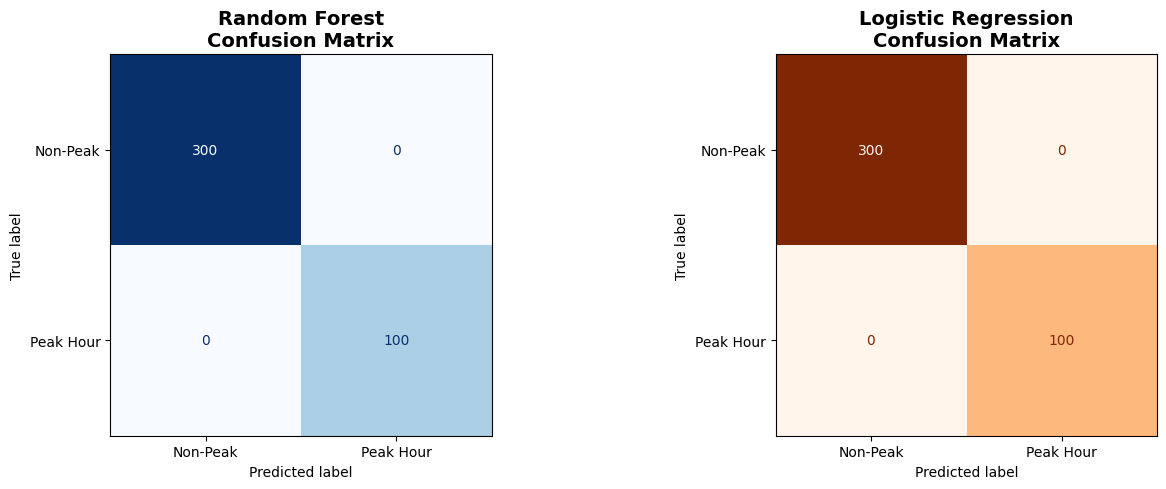

Confusion matrices saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, rf_preds)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['Non-Peak', 'Peak Hour'])
disp_rf.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest\nConfusion Matrix', fontsize=14, fontweight='bold')

cm_lr = confusion_matrix(y_test, lr_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                                  display_labels=['Non-Peak', 'Peak Hour'])
disp_lr.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Logistic Regression\nConfusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

In [ ]:
print("=" * 55)
print("RANDOM FOREST - Classification Report")
print("=" * 55)
print(classification_report(y_test, rf_preds,
                             target_names=['Non-Peak', 'Peak Hour']))

print("=" * 55)
print("LOGISTIC REGRESSION - Classification Report")
print("=" * 55)
print(classification_report(y_test, lr_preds,
                             target_names=['Non-Peak', 'Peak Hour']))

RANDOM FOREST - Classification Report
              precision    recall  f1-score   support

    Non-Peak       1.00      1.00      1.00       300
   Peak Hour       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

LOGISTIC REGRESSION - Classification Report
              precision    recall  f1-score   support

    Non-Peak       1.00      1.00      1.00       300
   Peak Hour       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [ ]:

rf_f1_test  = f1_score(y_test, rf_preds)
lr_f1_test  = f1_score(y_test, lr_preds)

print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Metric':<35} {'Random Forest':>10} {'Logistic Reg':>12}")
print("-" * 55)
print(f"{'CV Mean F1 (train)':<35} {rf_cv_scores.mean():>10.4f} {lr_cv_scores.mean():>12.4f}")
print(f"{'CV Std F1 (train)':<35} {rf_cv_scores.std():>10.4f} {lr_cv_scores.std():>12.4f}")
print(f"{'Test F1 Score':<35} {rf_f1_test:>10.4f} {lr_f1_test:>12.4f}")
print("-" * 55)

best = "Random Forest" if rf_f1_test >= lr_f1_test else "Logistic Regression"
print(f"\nBest Model (by Test F1): {best}")
print("\nNote: F1 score is used as primary metric because")
print("the dataset has class imbalance (75% non-peak, 25% peak).")

MODEL COMPARISON SUMMARY
Metric                              Random Forest Logistic Reg
-------------------------------------------------------
CV Mean F1 (train)                      1.0000       1.0000
CV Std F1 (train)                       0.0000       0.0000
Test F1 Score                           1.0000       1.0000
-------------------------------------------------------

Best Model (by Test F1): Random Forest

Note: F1 score is used as primary metric because
the dataset has class imbalance (75% non-peak, 25% peak).


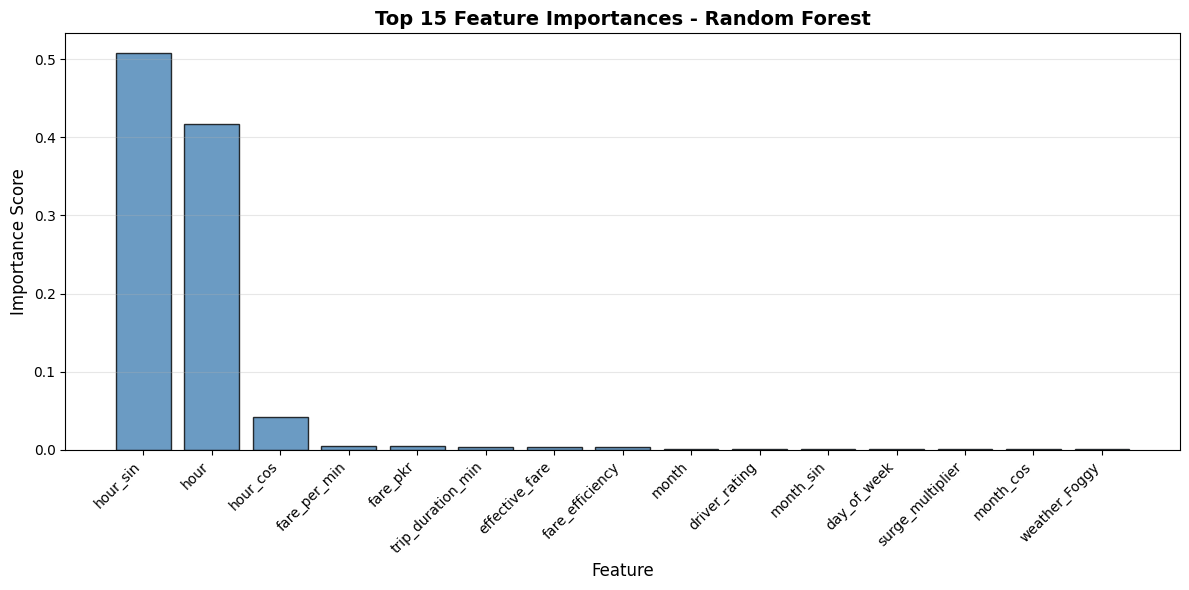

Feature importance chart saved!


In [ ]:

feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(12, 6))
plt.bar(range(15), importances[indices], color='steelblue', edgecolor='black', alpha=0.8)
plt.xticks(range(15), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 15 Feature Importances - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved!")

In [ ]:

joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(lr_pipeline, 'logistic_regression_model.pkl')

print("Models saved successfully!")
print("  -> random_forest_model.pkl")
print("  -> logistic_regression_model.pkl")

import os
rf_size = os.path.getsize('random_forest_model.pkl') / 1024
lr_size = os.path.getsize('logistic_regression_model.pkl') / 1024
print(f"\nFile sizes:")
print(f"  random_forest_model.pkl      : {rf_size:.1f} KB")
print(f"  logistic_regression_model.pkl: {lr_size:.1f} KB")

Models saved successfully!
  -> random_forest_model.pkl
  -> logistic_regression_model.pkl

File sizes:
  random_forest_model.pkl      : 225.0 KB
  logistic_regression_model.pkl: 2.9 KB
